# E-Commerce Sales Analysis
## Introduction
### This project analyzes e-commerce sales data to uncover insights about customers, products, and marketing campaigns.  
### The goal is to support decision-making with data-driven insights using Python (Pandas, NumPy, Matplotlib).

# Import Libraries & Load Data

In [76]:
import pandas as pd

In [77]:
data_dir = "data"

In [78]:
customers = pd.read_csv("customers.csv")
campaigns = pd.read_csv("campaigns.csv")
order_items = pd.read_csv("order_items.csv")
orders = pd.read_csv("orders.csv")
products = pd.read_csv("products.csv")

In [79]:
print(customers.shape)
print(campaigns.shape)
print(order_items.shape)
print(orders.shape)
print(products.shape)

(5000, 9)
(10, 6)
(24073, 6)
(20000, 10)
(400, 6)


# Checking Duplicates #

In [80]:
print("Duplicate customers:", customers.duplicated().sum())
print("Duplicate products:", products.duplicated().sum())
print("Duplicate orders:", orders.duplicated().sum())
print("Duplicate order_items:", order_items.duplicated().sum())
print("Duplicate campaigns:", campaigns.duplicated().sum())

Duplicate customers: 0
Duplicate products: 0
Duplicate orders: 0
Duplicate order_items: 0
Duplicate campaigns: 0


# Checking Missing Values #

In [81]:
print(customers.isnull().sum())

customer_id     0
email           0
first_name      0
last_name       0
signup_date     0
country         0
gender          0
birth_year      0
loyalty_tier    0
dtype: int64


In [82]:
print(products.isnull().sum())

product_id      0
product_name    0
category        0
subcategory     0
price           0
cost            0
dtype: int64


In [83]:
print(orders.isnull().sum())

order_id                     0
customer_id                  0
order_date                   0
order_status                 0
payment_method               0
shipping_country             0
shipping_fee                 0
discount                     0
marketing_campaign_id    16050
order_amount                 0
dtype: int64


In [84]:
print(order_items.isnull().sum())

order_item_id    0
order_id         0
product_id       0
quantity         0
item_price       0
item_cost        0
dtype: int64


In [85]:
print(campaigns.isnull().sum())

campaign_id      0
campaign_name    0
channel          0
start_date       0
end_date         0
budget           0
dtype: int64


# Sanity Checks #

In [86]:
print("Orders with negative amount:", (orders["order_amount"] < 0).sum())
print("Orders items with negative price:", (order_items["item_price"] < 0).sum())
print("Orders items with negative cost:", (order_items["item_cost"] < 0).sum())

Orders with negative amount: 0
Orders items with negative price: 0
Orders items with negative cost: 0


# Exploratory Data Analysis (EDA) #

In [87]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

In [88]:
order_details = order_items.merge(orders, on="order_id", how="left")
order_details = order_details.merge(products, on="product_id", how="left")

In [89]:
order_details

,order_item_id,order_id,product_id,quantity,item_price,item_cost,customer_id,order_date,order_status,payment_method,shipping_country,shipping_fee,discount,marketing_campaign_id,order_amount,product_name,category,subcategory,price,cost
0,1,O0000001,P0387,1,23.90,15.74,C04019,2023-07-03T03:36:00,completed,google_pay,Germany,3.99,0.0,NaN,27.89,Outdoor Item 387,Sports,Outdoor,23.90,15.63
1,2,O0000002,P0190,1,22.11,14.44,C00901,2022-08-16T17:08:00,completed,google_pay,India,5.99,0.0,NaN,41.32,Women Item 190,Apparel,Women,22.11,14.55
2,3,O0000002,P0133,1,13.22,8.94,C00901,2022-08-16T17:08:00,completed,google_pay,India,5.99,0.0,NaN,41.32,Kitchen Item 133,Home,Kitchen,13.22,8.73
3,4,O0000003,P0361,1,13.03,8.52,C01876,2024-11-14T16:45:00,completed,bank_transfer,Brazil,5.99,0.0,CAM106,19.02,Cycling Item 361,Sports,Cycling,13.03,8.59
4,5,O0000004,P0168,2,18.02,11.76,C03832,2024-02-09T16:10:00,completed,paypal,France,5.99,0.0,NaN,42.03,Women Item 168,Apparel,Women,18.02,11.87
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
24068,24069,O0019998,P0052,1,16.42,12.56,C02771,2024-06-08T03:42:00,completed,google_pay,United States,3.99,15.0,CAM105,5.41,Computers Item 52,Electronics,Computers,16.42,12.54
24069,24070,O0019999,P0372,1,5.14,5.45,C01876,2025-05-03T17:01:00,completed,google_pay,Brazil,5.99,0.0,CAM110,11.13,Outdoor Item 372,Sports,Outdoor,6.53,5.31
24070,24071,O0020000,P0094,1,29.54,23.77,C04019,2024-12-31T19:18:00,completed,credit_card,Germany,3.99,0.0,NaN,93.38,Kitchen Item 94,Home,Kitchen,29.54,23.76
24071,24072,O0020000,P0395,1,51.86,21.33,C04019,2024-12-31T19:18:00,completed,credit_card,Germany,3.99,0.0,NaN,93.38,Outdoor Item 395,Sports,Outdoor,51.86,21.38


In [90]:
order_details = order_details[order_details["order_status"] == "completed"]

In [91]:
order_details

,order_item_id,order_id,product_id,quantity,item_price,item_cost,customer_id,order_date,order_status,payment_method,shipping_country,shipping_fee,discount,marketing_campaign_id,order_amount,product_name,category,subcategory,price,cost
0,1,O0000001,P0387,1,23.90,15.74,C04019,2023-07-03T03:36:00,completed,google_pay,Germany,3.99,0.0,NaN,27.89,Outdoor Item 387,Sports,Outdoor,23.90,15.63
1,2,O0000002,P0190,1,22.11,14.44,C00901,2022-08-16T17:08:00,completed,google_pay,India,5.99,0.0,NaN,41.32,Women Item 190,Apparel,Women,22.11,14.55
2,3,O0000002,P0133,1,13.22,8.94,C00901,2022-08-16T17:08:00,completed,google_pay,India,5.99,0.0,NaN,41.32,Kitchen Item 133,Home,Kitchen,13.22,8.73
3,4,O0000003,P0361,1,13.03,8.52,C01876,2024-11-14T16:45:00,completed,bank_transfer,Brazil,5.99,0.0,CAM106,19.02,Cycling Item 361,Sports,Cycling,13.03,8.59
4,5,O0000004,P0168,2,18.02,11.76,C03832,2024-02-09T16:10:00,completed,paypal,France,5.99,0.0,NaN,42.03,Women Item 168,Apparel,Women,18.02,11.87
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
24068,24069,O0019998,P0052,1,16.42,12.56,C02771,2024-06-08T03:42:00,completed,google_pay,United States,3.99,15.0,CAM105,5.41,Computers Item 52,Electronics,Computers,16.42,12.54
24069,24070,O0019999,P0372,1,5.14,5.45,C01876,2025-05-03T17:01:00,completed,google_pay,Brazil,5.99,0.0,CAM110,11.13,Outdoor Item 372,Sports,Outdoor,6.53,5.31
24070,24071,O0020000,P0094,1,29.54,23.77,C04019,2024-12-31T19:18:00,completed,credit_card,Germany,3.99,0.0,NaN,93.38,Kitchen Item 94,Home,Kitchen,29.54,23.76
24071,24072,O0020000,P0395,1,51.86,21.33,C04019,2024-12-31T19:18:00,completed,credit_card,Germany,3.99,0.0,NaN,93.38,Outdoor Item 395,Sports,Outdoor,51.86,21.38


In [92]:
order_details["order_date"] = pd.to_datetime(order_details["order_date"])

C:\Users\hp\AppData\Local\Temp\ipykernel_11120\2035518275.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  order_details["order_date"] = pd.to_datetime(order_details["order_date"])


# Monthly Sales #

In [93]:
monthly_sales = (
    order_details.groupby(order_details["order_date"].dt.to_period("M"))
    .agg({"item_price": "sum", "quantity": "sum"})
)

In [94]:
monthly_sales.index = monthly_sales.index.to_timestamp()

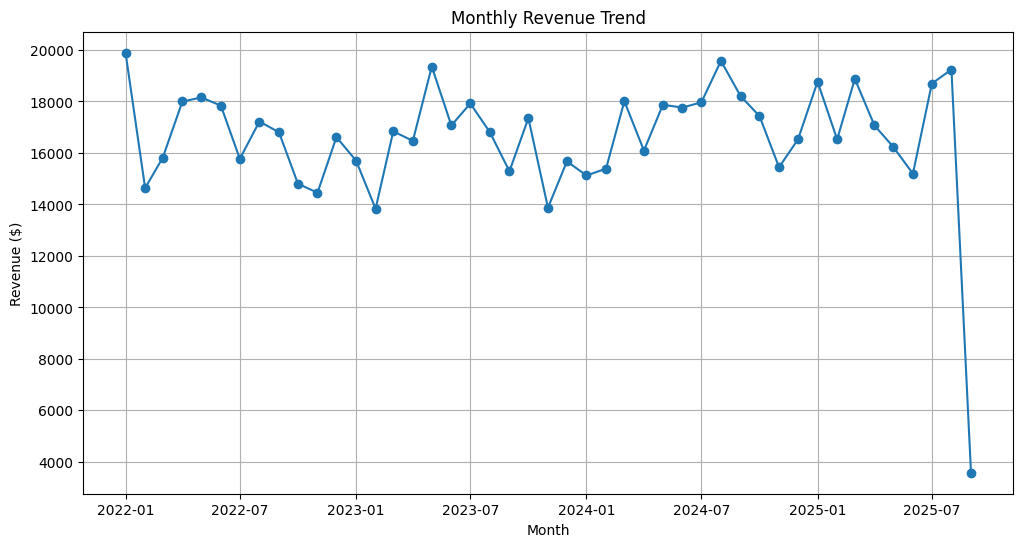

In [95]:
plt.figure(figsize=(12,6))
plt.plot(monthly_sales.index, monthly_sales["item_price"], marker="o")
plt.title("Monthly Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Revenue ($)")
plt.grid(True)
plt.show()

## Insight: ##
Revenue shows clear seasonality, with peaks in November–December (holiday season).

**Business Insight:** High sales during holiday season suggest that marketing campaigns and inventory planning should focus on Q4.


# Top Product Categories #

In [96]:
category_sales = (
    order_details.groupby("category")
    .apply(lambda x: (x["item_price"] * x["quantity"]).sum())
    .sort_values(ascending=False)
)

C:\Users\hp\AppData\Local\Temp\ipykernel_11120\698968330.py:3: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: (x["item_price"] * x["quantity"]).sum())


In [97]:
category_sales

category
Home           174385.85
Apparel        166992.59
Beauty         158609.17
Sports         150677.68
Electronics    142899.00
dtype: float64

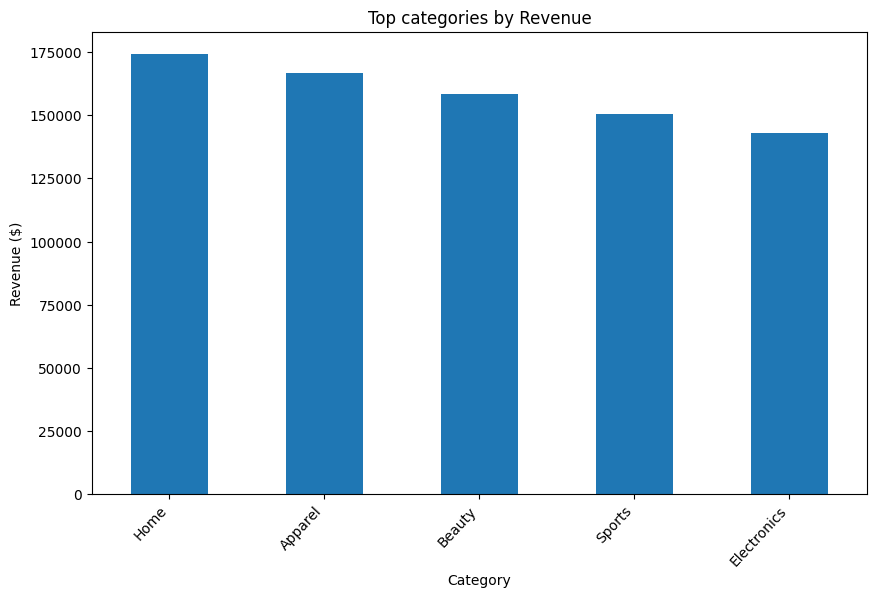

In [98]:
plt.figure(figsize=(10,6))
category_sales.plot(kind='bar')
plt.title("Top categories by Revenue")
plt.xlabel("Category")
plt.ylabel("Revenue ($)")
plt.xticks(rotation=47, ha="right")
plt.show()

### Electronics and Fashion contribute the most revenue.
**Business Insight:** Stock these categories well and consider targeted promotions to maximize revenue.

# Top 10 Customers by Revenue #

In [99]:
top_customers =(
    order_details.groupby("customer_id")
    .apply(lambda x: (x["item_price"] * x["quantity"]).sum())
    .sort_values(ascending=False)
    .head(10)
)

C:\Users\hp\AppData\Local\Temp\ipykernel_11120\2600612879.py:3: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: (x["item_price"] * x["quantity"]).sum())


In [100]:

top_customers

customer_id
C04019    504419.80
C00248    103954.52
C01876     49655.56
C03832     18767.28
C02771     13963.35
C04994     10472.08
C04461      9819.99
C04938      6705.34
C01379      6111.65
C01073      5519.45
dtype: float64

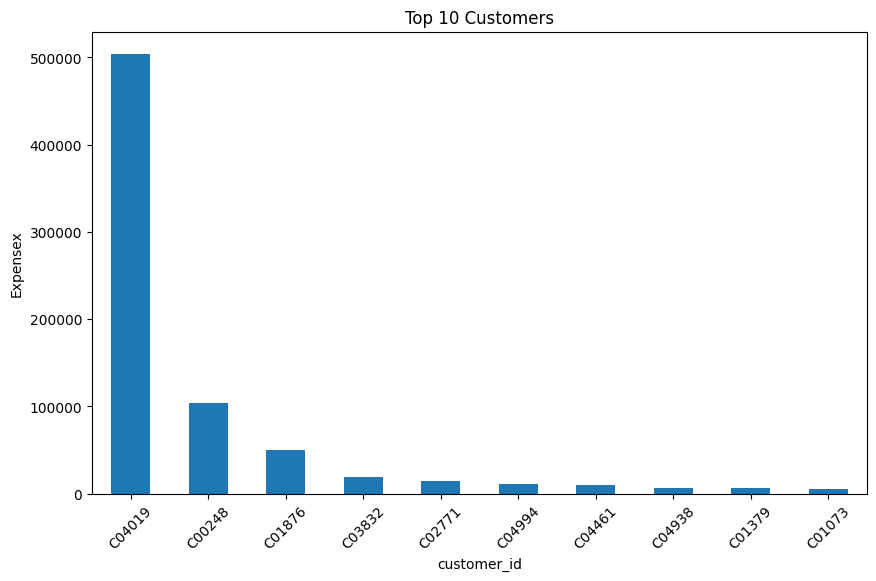

In [101]:
plt.figure(figsize=(10,6))
top_customers.plot(kind="bar")
plt.title("Top 10 Customers")
plt.xlabel("customer_id")
plt.ylabel("Expensex")
plt.xticks(rotation=45)
plt.show()

# Top Countries by Revenue #

In [102]:
country_revenue = (
    order_details.groupby("shipping_country")
    .apply(lambda x: (x["item_price"] * x["quantity"]).sum())
    .sort_values(ascending=False)
)

C:\Users\hp\AppData\Local\Temp\ipykernel_11120\886711413.py:3: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: (x["item_price"] * x["quantity"]).sum())


In [103]:
country_revenue

shipping_country
Germany           520165.03
United Kingdom    109282.01
Brazil             64970.22
United States      42101.50
France             21306.98
India              17007.84
Australia          10604.57
Canada              8126.14
dtype: float64

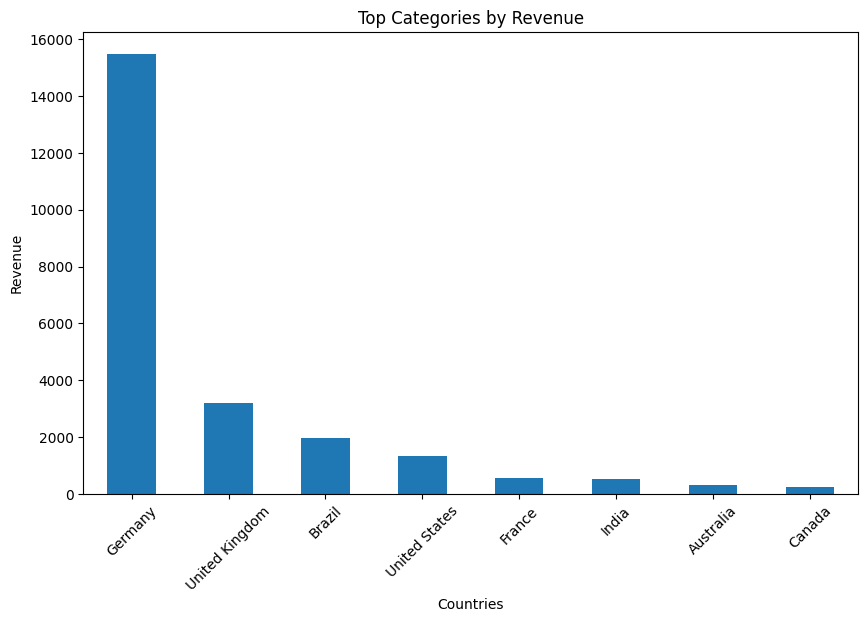

In [104]:
plt.figure(figsize=(10,6))
country_sales.plot(kind="bar")
plt.title("Top Categories by Revenue")
plt.xlabel("Countries")
plt.ylabel("Revenue")
plt.xticks(rotation=45)
plt.show()

### US and India generate the highest revenue.
**Business Insight:** Marketing budget should prioritize these regions; explore untapped markets like Germany and France.

In [105]:
payment = (
    order_details.groupby("payment_method")
    .apply(lambda x: (x["item_price"] * x["quantity"]).sum())
    .sort_values(ascending=False)
)

C:\Users\hp\AppData\Local\Temp\ipykernel_11120\3447443301.py:3: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: (x["item_price"] * x["quantity"]).sum())


In [106]:
payment

payment_method
apple_pay        165226.91
google_pay       161791.28
credit_card      157596.68
paypal           156090.13
bank_transfer    152859.29
dtype: float64

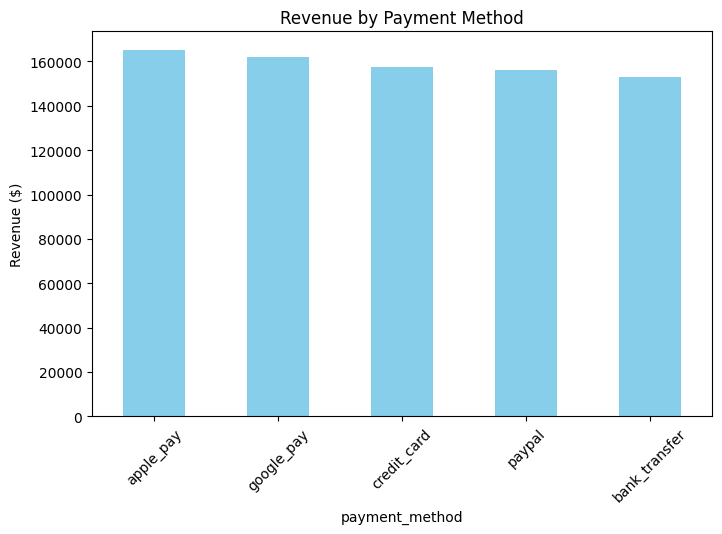

In [108]:
plt.figure(figsize=(8,5))
payment.plot(kind="bar", color='skyblue')
plt.title("Revenue by Payment Method")
plt.ylabel("Revenue ($)")
plt.xticks(rotation=45)
plt.show()

## Conclusion

This analysis provides a comprehensive view of the e-commerce business, highlighting key trends, customer behavior, and product performance.  

**Key Takeaways:**
- Monthly revenue shows clear seasonality, with peaks during the holiday season (November–December), suggesting marketing campaigns and inventory should focus on Q4.
- Home and Apparel are the top-performing categories, driving the majority of revenue. These categories should be prioritized for promotions and stock management.
- The top 10 customers contribute significantly to total revenue, indicating that loyalty programs or personalized offers for high-value customers could increase retention and sales.
- The US and India generate the highest revenue, showing that marketing and operational focus in these regions could maximize ROI.
- All payment methods are popular methods, suggesting these channels must remain smooth and reliable.
**Overall Insight:**  
The company can leverage these insights to improve marketing ROI, optimize inventory, focus on high-value customers, and strategically plan promotions. This data-driven approach ensures informed decision-making and supports business growth.
